In [2]:
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

print("repo:", ROOT)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

repo: /user/HS402/kd01071/Melanoma-Classification-Karthik
torch: 2.5.1+cu121 | cuda: True
gpu: NVIDIA RTX A4000


In [3]:
DATA = Path("/user/HS402/kd01071/Downloads/Melanoma-Classification-Group26")
TRAIN_CSV, TRAIN_DIR = DATA / "train.csv", DATA / "train"

df = pd.read_csv(TRAIN_CSV)
print(df.shape)
df.head(3)

(33126, 11)


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053


In [5]:
from src.audit_split import audit, patient_split, image_split, verify

df["patient_fold"] = patient_split(df)
df["image_fold"]   = image_split(df)

report = {
    "audit": audit(df, TRAIN_DIR),
    "patient_split": verify(df, "patient_fold"),
    "image_split": verify(df, "image_fold"),
}
print(json.dumps(report, indent=2))

{
  "audit": {
    "n_images": 33126,
    "n_patients": 2056,
    "duplicate_image_names": 0,
    "missing_image_files": 0,
    "n_positive": 584,
    "positive_rate": 0.01762965646320111,
    "imbalance_ratio": 55.72260273972603,
    "images_per_patient": {
      "mean": 16.111867704280154,
      "median": 12.0,
      "max": 115
    },
    "patients_with_melanoma": 428,
    "metadata_missing": {
      "age_approx": 68,
      "sex": 65,
      "anatom_site_general_challenge": 527
    }
  },
  "patient_split": {
    "shared_patients": 0,
    "val_images": 6627,
    "val_positives": 117,
    "val_positive_rate": 0.01765504753282028
  },
  "image_split": {
    "shared_patients": 1704,
    "val_images": 6626,
    "val_positives": 117,
    "val_positive_rate": 0.017657712043465137
  }
}


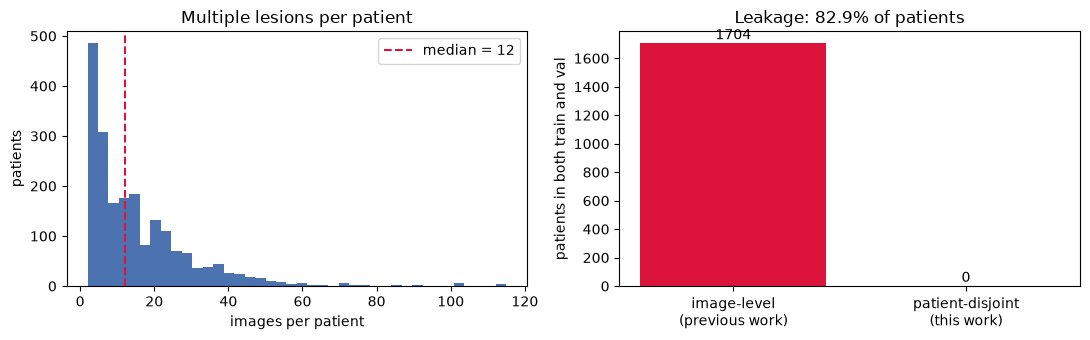

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

ipp = df.groupby("patient_id").size()
ax[0].hist(ipp, bins=40, color="#4C72B0")
ax[0].axvline(ipp.median(), color="crimson", ls="--",
              label=f"median = {ipp.median():.0f}")
ax[0].set(xlabel="images per patient", ylabel="patients",
          title="Multiple lesions per patient")
ax[0].legend()

shared = [report["image_split"]["shared_patients"], report["patient_split"]["shared_patients"]]
ax[1].bar(["image-level\n(previous work)", "patient-disjoint\n(this work)"],
          shared, color=["crimson", "#55A868"])
for i, v in enumerate(shared):
    ax[1].text(i, v + 30, str(v), ha="center")
ax[1].set(ylabel="patients in both train and val",
          title=f"Leakage: {shared[0]/df.patient_id.nunique():.1%} of patients")

plt.tight_layout()
Path(ROOT / "results").mkdir(exist_ok=True)
plt.savefig(ROOT / "results/fig1_leakage.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
from src.dataset import make_loaders

tr, va, META_DIM = make_loaders(
    csv=TRAIN_CSV, split_csv=ROOT/"splits/patient.csv", img_dir=TRAIN_DIR,
    fold_col="patient_fold", batch_size=32, balanced=True, workers=8)

img, meta, y = next(iter(tr))
print(f"meta_dim={META_DIM} | img{tuple(img.shape)} | batch pos rate {y.mean():.2f}")
print(f"train batches {len(tr)} | val batches {len(va)}")

/user/HS402/kd01071/Melanoma-Classification-Karthik/src/dataset.py:109: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double),


meta_dim=12 | img(32, 3, 224, 224) | batch pos rate 0.59
train batches 828 | val batches 104


In [8]:
from types import SimpleNamespace
from src.train import main as train_main

def run(name, balanced=False, use_metadata=False, drop=(),
        fold_col="patient_fold", split="splits/patient.csv", epochs=8, seed = 42):
    """Single entry point for every experiment: only the arguments change."""
    cfg = SimpleNamespace(
        name=name, csv=TRAIN_CSV, img_dir=TRAIN_DIR,
        split_csv=ROOT/split, fold_col=fold_col,
        balanced=balanced, use_metadata=use_metadata, drop=list(drop),
        epochs=epochs, lr=2e-5, batch_size=32, workers=8, seed=seed)
    train_main(cfg)
    return cfg

/user/HS402/kd01071/Melanoma-Classification-Karthik/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#run("E0_timing_probe", epochs=3)

In [8]:
#rm -rf results/E0_timing_probe logs/E0_timing_probe.jsonl

In [9]:
import time
t0 = time.time()

run("E0_baseline")                                          # no balancing, no metadata
run("E1_previous_wrs",  balanced=True)                      # your main-exam model
run("E2_multimodal",    balanced=True, use_metadata=True)   # new LSA model

run("E3_abl_image_only", balanced=True)                     # control for E2
run("E4_abl_no_age",     balanced=True, use_metadata=True, drop=["age"])
run("E5_abl_no_sex",     balanced=True, use_metadata=True, drop=["sex"])
run("E6_abl_no_site",    balanced=True, use_metadata=True, drop=["site"])

run("E7_imagelevel_wrs", balanced=True,                     # leakage comparison vs E1
    fold_col="image_fold", split="splits/image.csv")

print(f"total {(time.time()-t0)/60:.0f} min")

{"epoch": 0, "train_loss": 0.08143422615844846, "roc_auc": 0.8456450956450956, "pr_auc": 0.12178082974881, "recall": 0.0, "secs": 129.6}


{"epoch": 1, "train_loss": 0.07211486439351082, "roc_auc": 0.8720377591345332, "pr_auc": 0.10910107500893743, "recall": 0.0, "secs": 130.3}


{"epoch": 2, "train_loss": 0.0656676445097847, "roc_auc": 0.894816652881169, "pr_auc": 0.1587522814828468, "recall": 0.0, "secs": 131.3}


{"epoch": 3, "train_loss": 0.05786923106291876, "roc_auc": 0.8833444930219123, "pr_auc": 0.14968924704156014, "recall": 0.0, "secs": 130.7}


{"epoch": 4, "train_loss": 0.04864639024855344, "roc_auc": 0.8873403179854793, "pr_auc": 0.170129276714241, "recall": 0.02564102564102564, "secs": 129.3}


...

{"epoch": 3, "train_loss": 0.025154515049384586, "roc_auc": 0.8975107444918475, "pr_auc": 0.21625184380789048, "recall": 0.24786324786324787, "secs": 129.8}


{"epoch": 4, "train_loss": 0.007965842327815852, "roc_auc": 0.8813726687440007, "pr_auc": 0.21670961295230404, "recall": 0.19658119658119658, "secs": 130.4}


{"epoch": 5, "train_loss": 0.0039419862883460595, "roc_auc": 0.8949206424240991, "pr_auc": 0.21110970970159068, "recall": 0.1794871794871795, "secs": 130.2}


{"epoch": 6, "train_loss": 0.0021003292795636727, "roc_auc": 0.885694101395438, "pr_auc": 0.21271827233916446, "recall": 0.15384615384615385, "secs": 130.0}


{"epoch": 7, "train_loss": 0.0010138131001660028, "roc_auc": 0.8903208312487771, "pr_auc": 0.22115636817194698, "recall": 0.1452991452991453, "secs": 129.9}
[E7_imagelevel_wrs] best val ROC-AUC: 0.8975
total 139 min


In [9]:
from src.metrics import compute, bootstrap_ci

rows = []
for d in sorted((ROOT/"results").glob("E*/val_preds.npz")):
    z = np.load(d)
    y, p = z["y"], z["p"]
    m = compute(y, p)
    lo, hi = bootstrap_ci(y, p, "roc_auc")
    plo, phi = bootstrap_ci(y, p, "pr_auc")
    rows.append({
        "exp": d.parent.name, "epoch": int(z["epoch"]),
        "roc_auc": round(m["roc_auc"], 4), "roc_ci": f"[{lo:.3f}, {hi:.3f}]",
        "pr_auc": round(m["pr_auc"], 4), "pr_ci": f"[{plo:.3f}, {phi:.3f}]",
        "recall": round(m["recall"], 3), "precision": round(m["precision"], 3),
        "fn": m["fn"], "fp": m["fp"],
    })

tbl = pd.DataFrame(rows).sort_values("exp")
tbl.to_csv(ROOT/"results/master_table.csv", index=False)
tbl

,exp,epoch,roc_auc,roc_ci,pr_auc,pr_ci,recall,precision,fn,fp
0,E0_baseline,2,0.8948,"[0.872, 0.916]",0.1588,"[0.116, 0.234]",0.000,0.000,117,1
1,E1_previous_wrs,1,0.9034,"[0.877, 0.927]",0.1844,"[0.136, 0.259]",0.427,0.188,67,216
2,E1_seed0,0,0.8895,"[0.863, 0.918]",0.2075,"[0.149, 0.295]",0.650,0.114,41,590
3,E1_seed1,0,0.8990,"[0.872, 0.924]",0.2021,"[0.148, 0.279]",0.675,0.116,38,602
4,E2_multimodal,0,0.9050,"[0.883, 0.928]",0.1510,"[0.111, 0.204]",0.752,0.106,29,743
5,E2_seed0,0,0.9011,"[0.878, 0.923]",0.1917,"[0.139, 0.265]",0.564,0.144,51,392
6,E3_abl_image_only,1,0.9034,"[0.877, 0.927]",0.1844,"[0.136, 0.259]",0.427,0.188,67,216
7,E4_abl_no_age,0,0.9142,"[0.895, 0.935]",0.2200,"[0.162, 0.308]",0.726,0.102,32,748
8,E5_abl_no_sex,7,0.9140,"[0.894, 0.933]",0.2047,"[0.149, 0.282]",0.120,0.368,103,24
9,E6_abl_no_site,5,0.8997,"[0.874, 0.924]",0.1948,"[0.138, 0.267]",0.205,0.300,93,56


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

preds = {d.parent.name: np.load(d) for d in sorted((ROOT/"results").glob("E*/val_preds.npz"))}

def recall_at_fpr(y, p, target=0.10):
    """Sensitivity at a fixed false-positive rate — removes the threshold confound."""
    fpr, tpr, _ = roc_curve(y, p)
    return float(np.interp(target, fpr, tpr))

rows = []
for k, z in preds.items():
    y, p = z["y"], z["p"]
    rows.append({"exp": k, "epoch": int(z["epoch"]),
                 "recall@10%FPR": round(recall_at_fpr(y, p, 0.10), 3),
                 "recall@20%FPR": round(recall_at_fpr(y, p, 0.20), 3),
                 "recall@0.5thr": round((p[y==1] >= 0.5).mean(), 3)})
matched = pd.DataFrame(rows)
matched

,exp,epoch,recall@10%FPR,recall@20%FPR,recall@0.5thr
0,E0_baseline,2,0.615,0.846,0.000
1,E1_previous_wrs,1,0.735,0.863,0.427
2,E1_seed0,0,0.658,0.821,0.650
3,E1_seed1,0,0.675,0.838,0.675
4,E2_multimodal,0,0.701,0.889,0.752
5,E2_seed0,0,0.692,0.812,0.564
6,E3_abl_image_only,1,0.735,0.863,0.427
7,E4_abl_no_age,0,0.692,0.872,0.726
8,E5_abl_no_sex,7,0.692,0.855,0.120
9,E6_abl_no_site,5,0.726,0.821,0.205


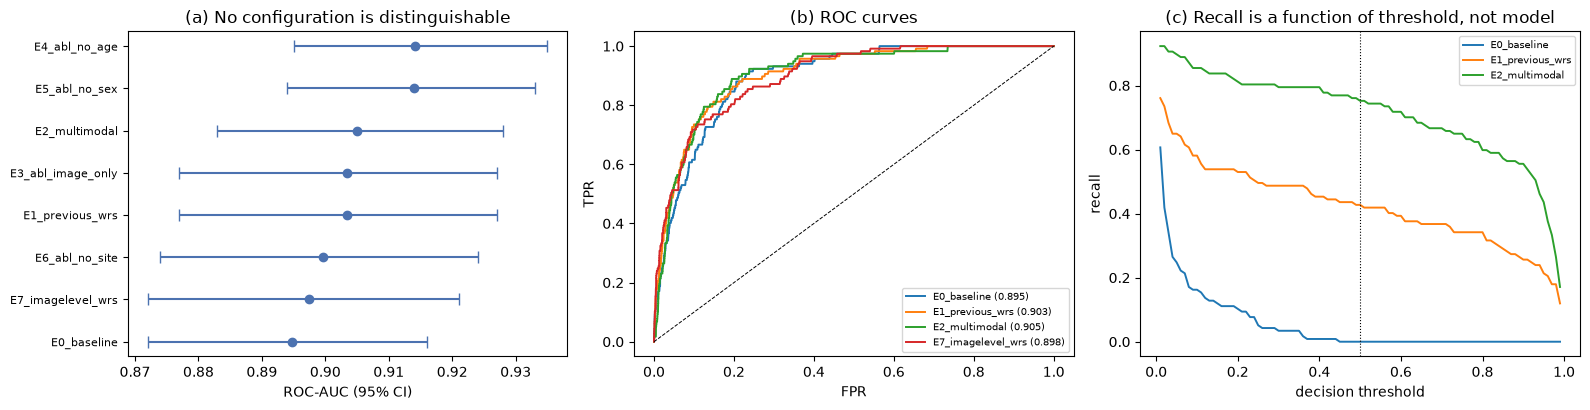

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) forest plot — CI overlap is the point
t = tbl.sort_values("roc_auc")
lo = [float(c.strip("[]").split(",")[0]) for c in t.roc_ci]
hi = [float(c.strip("[]").split(",")[1]) for c in t.roc_ci]
ax[0].errorbar(t.roc_auc, range(len(t)),
               xerr=[t.roc_auc-np.array(lo), np.array(hi)-t.roc_auc],
               fmt="o", capsize=4, color="#4C72B0")
ax[0].set_yticks(range(len(t))); ax[0].set_yticklabels(t.exp, fontsize=8)
ax[0].set(xlabel="ROC-AUC (95% CI)", title="(a) No configuration is distinguishable")

# (b) ROC curves — visually superimposed
for k in ["E0_baseline","E1_previous_wrs","E2_multimodal","E7_imagelevel_wrs"]:
    z = preds[k]; f, t_, _ = roc_curve(z["y"], z["p"])
    ax[1].plot(f, t_, lw=1.4, label=f"{k} ({auc(f,t_):.3f})")
ax[1].plot([0,1],[0,1],"k--",lw=.7)
ax[1].set(xlabel="FPR", ylabel="TPR", title="(b) ROC curves"); ax[1].legend(fontsize=7)

# (c) threshold sweep — where the "differences" actually come from
for k in ["E0_baseline","E1_previous_wrs","E2_multimodal"]:
    z = preds[k]; y, p = z["y"], z["p"]
    thr = np.linspace(0.01, 0.99, 99)
    ax[2].plot(thr, [(p[y==1] >= t).mean() for t in thr], lw=1.4, label=k)
ax[2].axvline(0.5, color="k", ls=":", lw=.8)
ax[2].set(xlabel="decision threshold", ylabel="recall",
          title="(c) Recall is a function of threshold, not model")
ax[2].legend(fontsize=7)

plt.tight_layout(); plt.savefig(ROOT/"results/fig2_results.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
for s in [0, 1]:
    run(f"E1_seed{s}", balanced=True, seed=s)
    run(f"E2_seed{s}", balanced=True, use_metadata=True, seed=s)

{"epoch": 0, "train_loss": 0.26895197051136355, "roc_auc": 0.8894790394790395, "pr_auc": 0.2074523521166126, "recall": 0.6495726495726496, "secs": 125.1}


{"epoch": 1, "train_loss": 0.08575649076332068, "roc_auc": 0.8694263920070371, "pr_auc": 0.1610392152098542, "recall": 0.4358974358974359, "secs": 121.1}


{"epoch": 2, "train_loss": 0.039708087035128056, "roc_auc": 0.8656261898197383, "pr_auc": 0.19253322157537472, "recall": 0.3247863247863248, "secs": 132.2}


{"epoch": 3, "train_loss": 0.01758892254965846, "roc_auc": 0.8459378733572283, "pr_auc": 0.12666575546090963, "recall": 0.21367521367521367, "secs": 133.4}


{"epoch": 4, "train_loss": 0.014586285470987266, "roc_auc": 0.8682611892289311, "pr_auc": 0.15349485754296396, "recall": 0.13675213675213677, "secs": 132.5}


...

{"epoch": 3, "train_loss": 0.02284058279323123, "roc_auc": 0.8568113487468326, "pr_auc": 0.1412173707183532, "recall": 0.1282051282051282, "secs": 131.8}


{"epoch": 4, "train_loss": 0.011763075973982962, "roc_auc": 0.8705417044126722, "pr_auc": 0.13372038973550907, "recall": 0.1623931623931624, "secs": 127.4}


{"epoch": 5, "train_loss": 0.005589906642203481, "roc_auc": 0.8543588430685205, "pr_auc": 0.1402848231059077, "recall": 0.11965811965811966, "secs": 129.1}


{"epoch": 6, "train_loss": 0.0017968702279642528, "roc_auc": 0.8541999816193365, "pr_auc": 0.1468358848285397, "recall": 0.10256410256410256, "secs": 126.9}


{"epoch": 7, "train_loss": 0.0009043639181077043, "roc_auc": 0.8553953812018328, "pr_auc": 0.14058027928157502, "recall": 0.06837606837606838, "secs": 123.3}
[E2_seed1] best val ROC-AUC: 0.8958


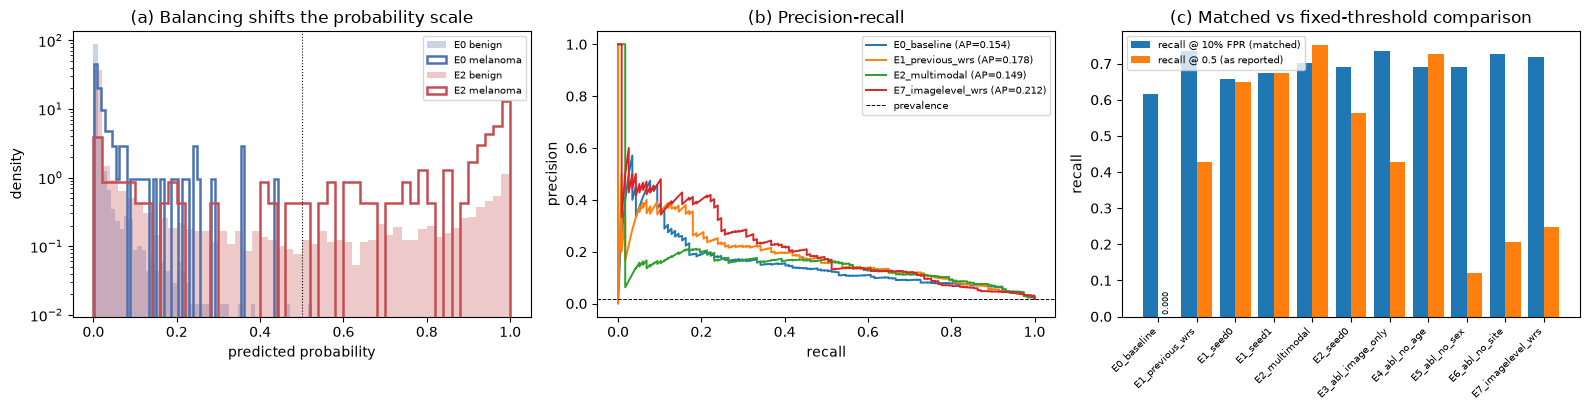

In [21]:
plt.close("all")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) where the probability mass sits — two models only, for readability
for k, c in [("E0_baseline", "#4C72B0"), ("E2_multimodal", "#C44E52")]:
    z = preds[k]; y, p = z["y"], z["p"]
    ax[0].hist(p[y==0], bins=50, alpha=.30, density=True, color=c,
               label=f"{k.split('_')[0]} benign")
    ax[0].hist(p[y==1], bins=50, density=True, histtype="step", lw=1.8, color=c,
               label=f"{k.split('_')[0]} melanoma")
ax[0].axvline(.5, color="k", ls=":", lw=.8)
ax[0].set(xlabel="predicted probability", ylabel="density", yscale="log",
          title="(a) Balancing shifts the probability scale")
ax[0].legend(fontsize=7)

# (b) PR curves — the honest view at 1.76% prevalence
for k in ["E0_baseline", "E1_previous_wrs", "E2_multimodal", "E7_imagelevel_wrs"]:
    z = preds[k]; pr, rc, _ = precision_recall_curve(z["y"], z["p"])
    ax[1].plot(rc, pr, lw=1.4, label=f"{k} (AP={auc(rc,pr):.3f})")
ax[1].axhline(0.0176, color="k", ls="--", lw=.7, label="prevalence")
ax[1].set(xlabel="recall", ylabel="precision", title="(b) Precision-recall")
ax[1].legend(fontsize=7)

# (c) the confound, quantified
m = matched.set_index("exp")
x = np.arange(len(m))
ax[2].bar(x-0.2, m["recall@10%FPR"], .4, label="recall @ 10% FPR (matched)")
ax[2].bar(x+0.2, m["recall@0.5thr"], .4, label="recall @ 0.5 (as reported)")
for i, v in enumerate(m["recall@0.5thr"]):
    if v == 0:
        ax[2].text(i+0.2, 0.01, "0.000", ha="center", fontsize=6, rotation=90)
ax[2].set_xticks(x); ax[2].set_xticklabels(m.index, rotation=45, ha="right", fontsize=7)
ax[2].set(ylabel="recall", title="(c) Matched vs fixed-threshold comparison")
ax[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(ROOT/"results/fig3_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
pd.set_option("display.max_rows", None)

# Failure modes and subgroup bias — the two items the marker named explicitly
meta = pd.read_csv(TRAIN_CSV)
val = pd.read_csv(ROOT/"splits/patient.csv").query("patient_fold=='val'")
val = val.merge(meta, on=["image_name","patient_id","target"])

z = preds["E2_multimodal"]                       # change name if you prefer E1
val = val.assign(prob=z["p"], y=z["y"])
assert (val.y == val.target).all(), "prediction order mismatch"

# operating point: 10% FPR, matched across models
thr = np.quantile(val.prob[val.target==0], 0.90)
val["pred"] = (val.prob >= thr).astype(int)
print(f"threshold @10% FPR = {thr:.4f} | recall = {val.pred[val.target==1].mean():.3f}\n")

# --- worst false negatives: melanomas the model was most confident were benign
fn = val[(val.target==1) & (val.pred==0)].nsmallest(10, "prob")
print("WORST MISSED MELANOMAS")
print(fn[["image_name","prob","sex","age_approx","anatom_site_general_challenge"]]
      .to_string(index=False), "\n")

# --- what do the misses have in common?
allpos = val[val.target==1]
miss = val[(val.target==1) & (val.pred==0)]
for col in ["sex","anatom_site_general_challenge"]:
    comp = pd.DataFrame({"all_melanoma": allpos[col].value_counts(normalize=True),
                         "missed": miss[col].value_counts(normalize=True)}).round(3)
    print(f"--- {col} ---\n{comp}\n")
print(f"age: all melanoma {allpos.age_approx.mean():.1f} | missed {miss.age_approx.mean():.1f}\n")

# --- subgroup performance, always with counts
def subgroup(df, col):
    out = []
    for g, d in df.groupby(col, dropna=False):
        pos = int(d.target.sum())
        out.append({col: g, "n": len(d), "pos": pos,
                    "recall": round(d.pred[d.target==1].mean(), 3) if pos else np.nan,
                    "fpr": round(d.pred[d.target==0].mean(), 3)})
    return pd.DataFrame(out).sort_values("pos", ascending=False)

for col in ["sex","anatom_site_general_challenge"]:
    print(f"=== {col} ===\n{subgroup(val, col).to_string(index=False)}\n")

val["age_band"] = pd.cut(val.age_approx, [0,40,55,70,100])
print(f"=== age ===\n{subgroup(val,'age_band').to_string(index=False)}")

threshold @10% FPR = 0.6169 | recall = 0.701

WORST MISSED MELANOMAS
  image_name     prob    sex  age_approx anatom_site_general_challenge
ISIC_0149568 0.000077 female        55.0               upper extremity
ISIC_9022005 0.000077 female        55.0               upper extremity
ISIC_7763042 0.000185 female        45.0               lower extremity
ISIC_8207974 0.002166 female        45.0                         torso
ISIC_4967586 0.002621   male        60.0               upper extremity
ISIC_1159891 0.002834 female        50.0                         torso
ISIC_8450656 0.003052 female        30.0                   palms/soles
ISIC_7242384 0.003839   male        45.0                         torso
ISIC_2979268 0.009413   male        50.0                         torso
ISIC_2607827 0.028275   male        60.0               upper extremity 

--- sex ---
        all_melanoma  missed
sex                         
male           0.607   0.543
female         0.393   0.457

--- anatom_site_gen

In [16]:
lines = []
allpos = val[val.target == 1]
miss = val[(val.target == 1) & (val.pred == 0)]

for col in ["sex", "anatom_site_general_challenge"]:
    comp = pd.DataFrame({"all_melanoma": allpos[col].value_counts(normalize=True),
                         "missed": miss[col].value_counts(normalize=True)}).round(3)
    lines.append(f"--- {col} ---\n{comp.to_string()}\n")

for col in ["sex", "anatom_site_general_challenge", "age_band"]:
    lines.append(f"=== subgroup: {col} ===\n{subgroup(val, col).to_string(index=False)}\n")

out = "\n".join(lines)
(ROOT / "results/failure_subgroup.txt").write_text(out)
print(out)

--- sex ---
        all_melanoma  missed
sex                         
male           0.607   0.543
female         0.393   0.457

--- anatom_site_general_challenge ---
                               all_melanoma  missed
anatom_site_general_challenge                      
head/neck                             0.138   0.057
lower extremity                       0.164   0.171
oral/genital                          0.026     NaN
palms/soles                           0.009   0.029
torso                                 0.466   0.514
upper extremity                       0.198   0.229

=== subgroup: sex ===
   sex    n  pos  recall   fpr
  male 3295   71   0.732 0.102
female 3332   46   0.652 0.098

=== subgroup: anatom_site_general_challenge ===
anatom_site_general_challenge    n  pos  recall   fpr
                        torso 3301   54   0.667 0.102
              upper extremity  947   23   0.652 0.084
              lower extremity 1745   19   0.684 0.079
                    head/neck  436  

In [14]:
from sklearn.metrics import roc_auc_score
seeds = {}
for k in ["E1_previous_wrs","E1_seed0","E1_seed1","E2_multimodal","E2_seed0","E2_seed1"]:
    z = np.load(ROOT/f"results/{k}/val_preds.npz")
    seeds[k] = roc_auc_score(z["y"], z["p"])
s = pd.DataFrame([
    {"config":"E1 image-only", **{f"seed{i}":round(seeds[k],4) for i,k in
        zip([42,0,1],["E1_previous_wrs","E1_seed0","E1_seed1"])}},
    {"config":"E2 multimodal", **{f"seed{i}":round(seeds[k],4) for i,k in
        zip([42,0,1],["E2_multimodal","E2_seed0","E2_seed1"])}},
])
s["mean"] = s[["seed42","seed0","seed1"]].mean(1).round(4)
s["sd"]   = s[["seed42","seed0","seed1"]].std(1).round(4)
s.to_csv(ROOT/"results/seed_variance.csv", index=False)
s

/tmp/ipykernel_2540025/2672254882.py:12: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  s["mean"] = s[["seed42","seed0","seed1"]].mean(1).round(4)
/tmp/ipykernel_2540025/2672254882.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of std will be keyword-only.
  s["sd"]   = s[["seed42","seed0","seed1"]].std(1).round(4)


,config,seed42,seed0,seed1,mean,sd
0,E1 image-only,0.9034,0.8895,0.8990,0.8973,0.0071
1,E2 multimodal,0.9050,0.9011,0.8958,0.9006,0.0046


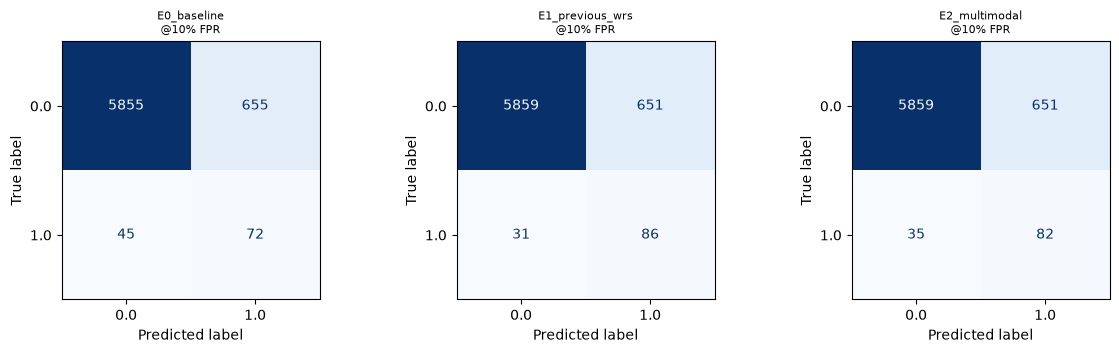

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, k in zip(ax, ["E0_baseline", "E1_previous_wrs", "E2_multimodal"]):
    z = preds[k]; y, p = z["y"], z["p"]
    t = np.quantile(p[y == 0], 0.90)          # matched 10% FPR
    ConfusionMatrixDisplay.from_predictions(y, (p >= t).astype(int), ax=a,
                                            colorbar=False, cmap="Blues")
    a.set_title(f"{k}\n@10% FPR", fontsize=8)
plt.tight_layout(); plt.savefig(ROOT/"results/fig4_confusion.png", dpi=200,
                                bbox_inches="tight"); plt.show()